In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io
from PIL import Image
import os

%matplotlib inline

ЗАГРУЗКА ДАННЫХ MNIST

In [ ]:
# Загрузка MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


ВИЗУАЛИЗАЦИЯ ДАННЫХ

In [ ]:
# Классы для MNIST (цифры 0-9)
classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

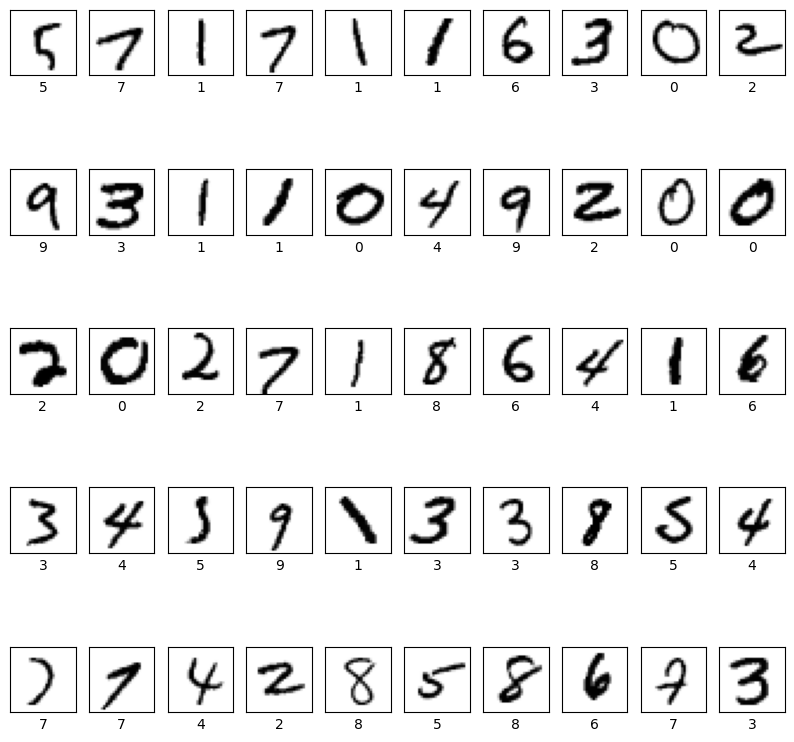

In [ ]:
# Создание поля для отображения 50 примеров цифр
plt.figure(figsize=(10,10))
for i in range(100,150):
    plt.subplot(5,10,i-100+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(classes[y_train[i]])

ПОДГОТОВКА ДАННЫХ

In [ ]:
# Подготовка данных для полносвязной сети
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

In [ ]:
# Нормализация данных
x_train = x_train / 255
x_test = x_test / 255

In [ ]:
# Преобразование меток в one-hot encoding формат
y_train_categorical = utils.to_categorical(y_train, 10)
y_test_categorical = utils.to_categorical(y_test, 10)

СОЗДАНИЕ ПОЛНОСВЯЗНОЙ НЕЙРОННОЙ СЕТИ

In [ ]:
# Полносвязная сеть
model_dense = Sequential()
# Добавление входного полносвязного слоя с 800 нейронами и функцией активации ReLU
model_dense.add(Dense(800, input_dim=784, activation="relu"))
# Добавление выходного слоя с 10 нейронами (по количеству цифр) и функцией активации softmax
model_dense.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Компиляция модели с указанием функции потерь, оптимизатора и метрики качества
model_dense.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model_dense.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 800)            │       628,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 636,010 (2.43 MB)

 Trainable params: 636,010 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

 ОБУЧЕНИЕ ПОЛНОСВЯЗНОЙ СЕТИ

In [ ]:
# Обучение полносвязной сети
history_dense = model_dense.fit(x_train, y_train_categorical,
                                batch_size=200,
                                epochs=10,
                                validation_split=0.2,
                                verbose=1)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8414 - loss: 0.5515 - val_accuracy: 0.9540 - val_loss: 0.1595
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9605 - loss: 0.1393 - val_accuracy: 0.9682 - val_loss: 0.1107
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9764 - loss: 0.0850 - val_accuracy: 0.9718 - val_loss: 0.0955
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9844 - loss: 0.0573 - val_accuracy: 0.9719 - val_loss: 0.0893
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9873 - loss: 0.0449 - val_accuracy: 0.9753 - val_loss: 0.0802
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9924 - loss: 0.0294 - val_accuracy: 0.9779 - val_loss: 0.0749
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9951 - loss: 0.0208 - val_accuracy: 0.9772 - val_loss: 0.0762
Epoch 8/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9969 - loss: 0.0167 - val_acc

ПОДГОТОВКА ДАННЫХ ДЛЯ СВЕРТОЧНОЙ СЕТИ


In [ ]:
# Подготовка данных для сверточной сети
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

 СОЗДАНИЕ СВЕРТОЧНОЙ НЕЙРОННОЙ СЕТИ

In [ ]:
# Сверточная сеть
model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Компиляция сверточной модели
model_cnn.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

ОБУЧЕНИЕ СВЕРТОЧНОЙ СЕТИ

In [ ]:
# Обучение сверточной сети
history_cnn = model_cnn.fit(x_train_cnn, y_train_categorical,
                            batch_size=200,
                            epochs=10,
                            validation_split=0.2,
                            verbose=1)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 42s 167ms/step - accuracy: 0.8169 - loss: 0.6435 - val_accuracy: 0.9722 - val_loss: 0.0898
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 40s 165ms/step - accuracy: 0.9758 - loss: 0.0787 - val_accuracy: 0.9773 - val_loss: 0.0770
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 39s 163ms/step - accuracy: 0.9823 - loss: 0.0547 - val_accuracy: 0.9836 - val_loss: 0.0557
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 39s 163ms/step - accuracy: 0.9875 - loss: 0.0398 - val_accuracy: 0.9830 - val_loss: 0.0568
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 39s 163ms/step - accuracy: 0.9908 - loss: 0.0313 - val_accuracy: 0.9875 - val_loss: 0.0436
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 40s 168ms/step - accuracy: 0.9930 - loss: 0.0244 - val_accuracy: 0.9871 - val_loss: 0.0458
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 40s 163ms/step - accuracy: 0.9933 - loss: 0.0196 - val_accuracy: 0.9888 - val_loss: 0.0421
Epoch 8/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 40s 168ms/step - accuracy: 0.9944 - loss: 0

ФУНКЦИЯ ДЛЯ ПРЕДСКАЗАНИЯ НА ПОЛЬЗОВАТЕЛЬСКИХ ИЗОБРАЖЕНИЯХ

In [ ]:
def predict_custom_image(model, img_path, model_type='dense'):
    # Загрузка и конвертация изображения в черно-белый формат
    img = Image.open(img_path).convert('L')
    # Изменение размера до 28x28 пикселей
    img = img.resize((28, 28))
    # Преобразование в numpy array и нормализация
    img_array = np.array(img) / 255.0
    # Подготовка данных в зависимости от типа модели
    if model_type == 'dense':
        img_array = img_array.reshape(1, 784)  # Для полносвязной сети
    else:  # Для сверточной сети
        img_array = img_array.reshape(1, 28, 28, 1)
    # Получение предсказания от модели
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)  # Класс с максимальной вероятностью
    confidence = np.max(prediction)  # Уровень уверенности
    # Визуализация результата
    plt.imshow(img, cmap='gray')
    plt.title(f'Предсказано: {predicted_class} (уверенность: {confidence:.2f})')
    plt.axis('off')
    plt.show()
    return predicted_class, confidence

ЗАГРУЗКА ПОЛЬЗОВАТЕЛЬСКИХ ИЗОБРАЖЕНИЙ

In [ ]:
# Загрузка пользовательских изображений
uploaded = files.upload()

Saving 0.jpg to 0.jpg
Saving 1.jpg to 1.jpg
Saving 2.jpg to 2.jpg
Saving 3.jpg to 3.jpg
Saving 4.jpg to 4.jpg
Saving 5.jpg to 5.jpg
Saving 6.jpg to 6.jpg
Saving 7.jpg to 7.jpg
Saving 8.jpg to 8.jpg
Saving 9.jpg to 9.jpg


In [ ]:
# Создание папки для сохранения
if not os.path.exists('custom_digits'):
    os.makedirs('custom_digits')

In [ ]:
# Сохранение загруженных файлов
for filename in uploaded.keys():
    with open(f'custom_digits/{filename}', 'wb') as f:
        f.write(uploaded[filename])

ТЕСТИРОВАНИЕ НА ЗАГРУЖЕННЫХ ИЗОБРАЖЕНИЯХ

Тестирование полносвязной сети:

Анализ 3.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


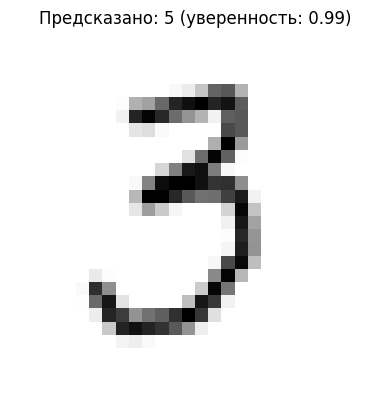


Анализ 6.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


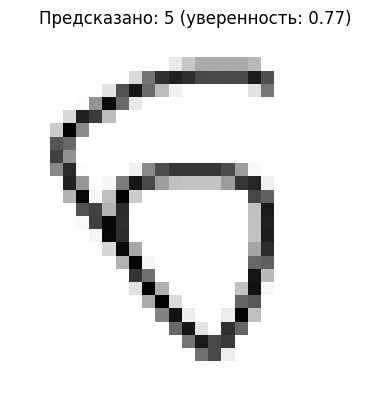


Анализ 8.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


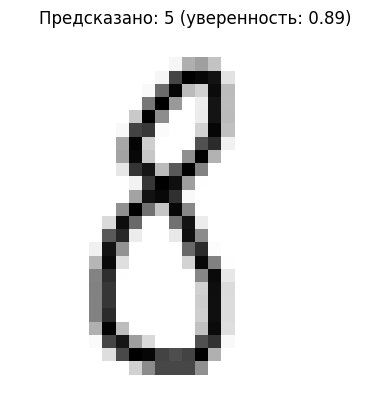


Анализ 5.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


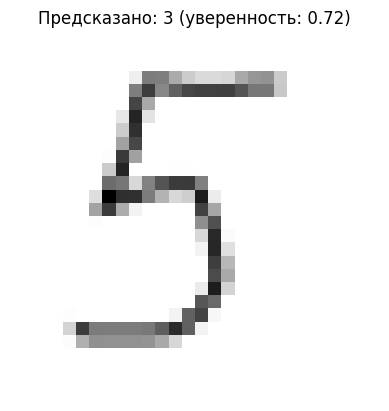


Анализ 1.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


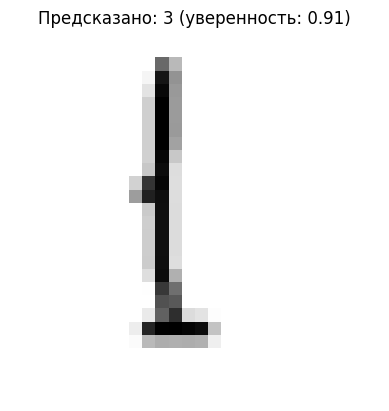


Анализ 2.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


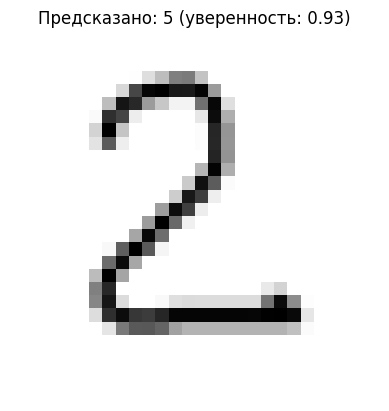


Анализ 0.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


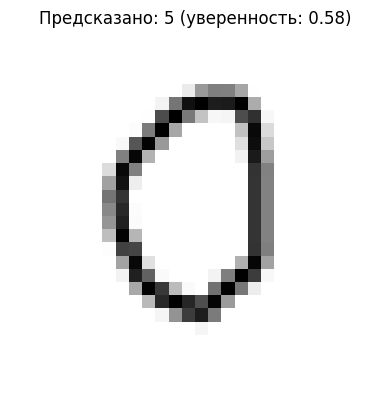


Анализ 9.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


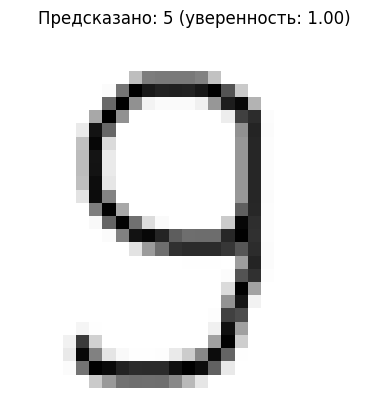


Анализ 4.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


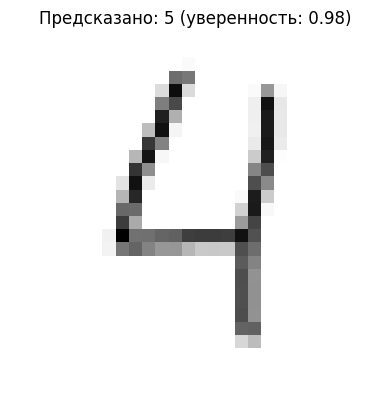


Анализ 7.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


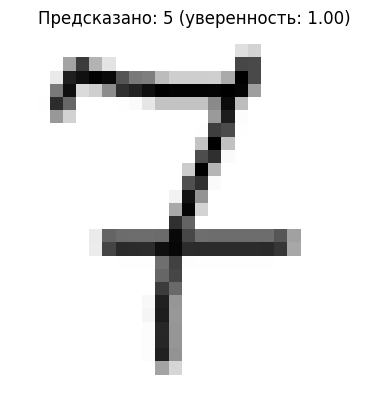

In [ ]:
# Тестирование на загруженных изображениях
print("Тестирование полносвязной сети:")
for filename in os.listdir('custom_digits'):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        print(f"\nАнализ {filename}:")
        predict_custom_image(model_dense, f'custom_digits/{filename}', 'dense')


Тестирование сверточной сети:

Анализ 3.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


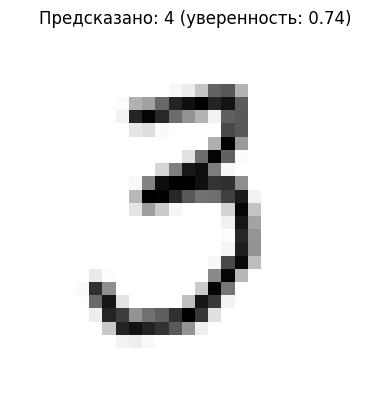


Анализ 6.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


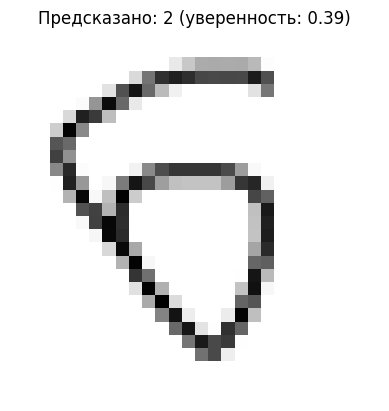


Анализ 8.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


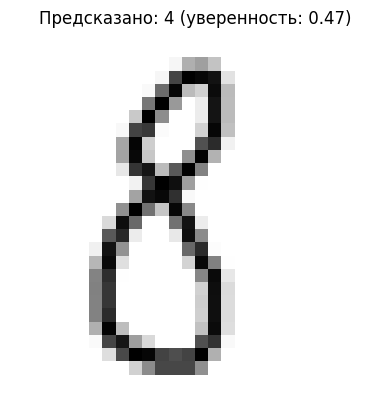


Анализ 5.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


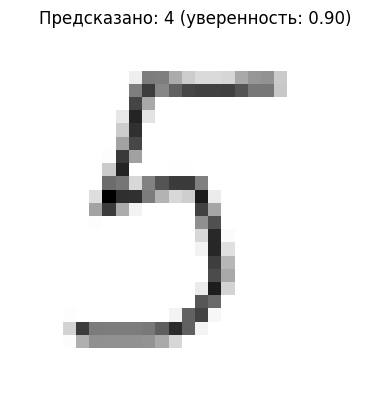


Анализ 1.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


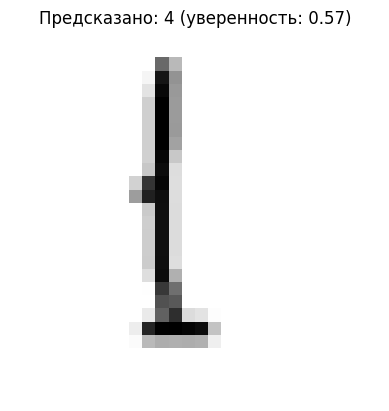


Анализ 2.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


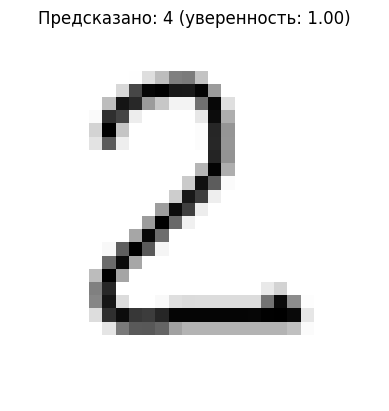


Анализ 0.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


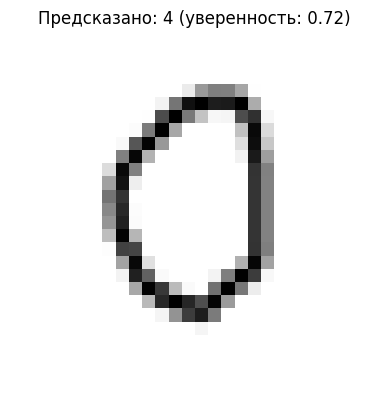


Анализ 9.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


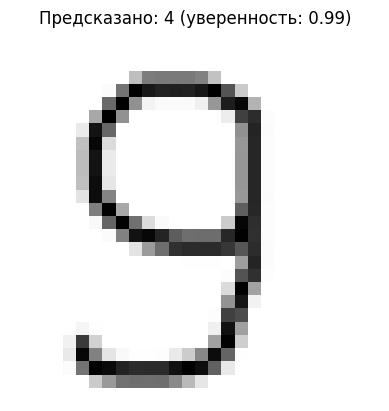


Анализ 4.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


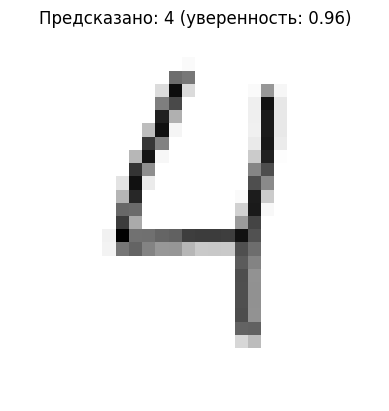


Анализ 7.jpg:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


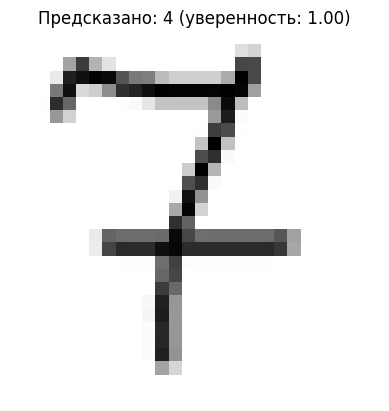

In [ ]:
print("\nТестирование сверточной сети:")
for filename in os.listdir('custom_digits'):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        print(f"\nАнализ {filename}:")
        predict_custom_image(model_cnn, f'custom_digits/{filename}', 'cnn')

СРАВНЕНИЕ ТОЧНОСТИ МОДЕЛЕЙ

In [ ]:
# Сравнение точности моделей
test_loss_dense, test_acc_dense = model_dense.evaluate(x_test, y_test_categorical, verbose=0)
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_cnn, y_test_categorical, verbose=0)

In [ ]:
print(f"\nСравнение результатов:")
print(f"Точность полносвязной сети на тестовых данных: {test_acc_dense:.4f}")
print(f"Точность сверточной сети на тестовых данных: {test_acc_cnn:.4f}")


Сравнение результатов:
Точность полносвязной сети на тестовых данных: 0.9809
Точность сверточной сети на тестовых данных: 0.9896


АНАЛИЗ ОШИБОК КЛАССИФИКАЦИИ

In [ ]:
# Анализ сложных случаев
predictions = model_dense.predict(x_test)
wrong_predictions = []
for i in range(len(x_test)):
    if np.argmax(predictions[i]) != y_test[i]:
        wrong_predictions.append(i)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
print(f"\nКоличество ошибок полносвязной сети: {len(wrong_predictions)}")


Количество ошибок полносвязной сети: 191


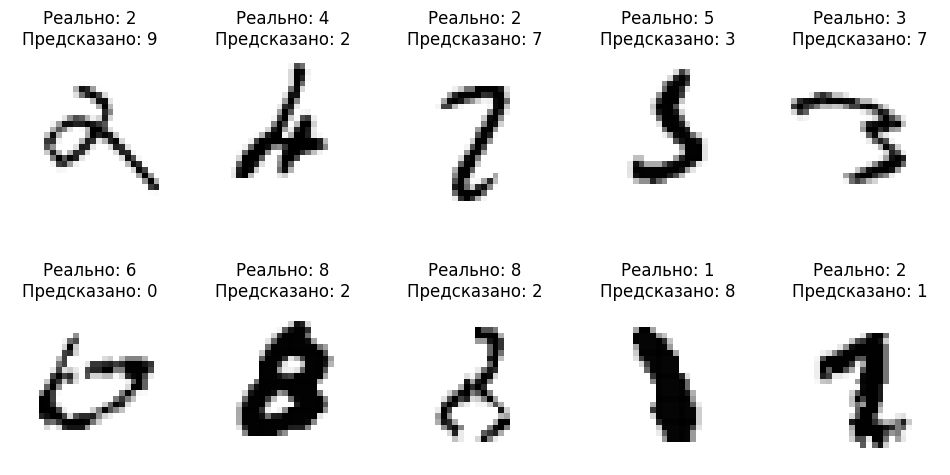

In [ ]:
# Визуализация некоторых ошибок
plt.figure(figsize=(12,6))
for i, wrong_idx in enumerate(wrong_predictions[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[wrong_idx].reshape(28,28), cmap=plt.cm.binary)
    plt.title(f'Реально: {y_test[wrong_idx]}\nПредсказано: {np.argmax(predictions[wrong_idx])}')
    plt.axis('off')